# 6.39 - CertCF LiRPA Backend Ablation on HELOC

Small diagnostic notebook to compare CROWN-style LiRPA backends on the same HELOC support points. The goal is to check whether stronger backends materially change center-certification outcomes relative to their build cost.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from certcf import NearestOppositeClassClearanceStrategy
from counterfactuals.datasets.loaders import HELOCDataset
from counterfactuals.methods.certcf import CertCF
from scripts.benchmark import _build_torch_model_from_checkpoint

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 120})

DATASET = 'heloc'
SEED = 42
N_SUPPORT = 300
ALPHA = 0.20
NORM = 1
CLASSIFICATION_MARGIN = 1.0e-4
DEVICE = 'auto'
CHECKPOINT = ROOT / 'checkpoints/heloc_classifier/best.ckpt'

LIRPA_METHODS = ['backward', 'crown-optimized', 'alpha-crown']
VARIANTS = [('adaptive shrink', True)]

rng = np.random.default_rng(SEED)
print({'dataset': DATASET, 'n_support': N_SUPPORT, 'alpha': ALPHA, 'lirpa_methods': LIRPA_METHODS, 'variant': 'adaptive shrink'})


{'dataset': 'heloc', 'n_support': 300, 'alpha': 0.2, 'lirpa_methods': ['backward', 'crown-optimized', 'alpha-crown'], 'variant': 'adaptive shrink'}


## Load HELOC And Sample Support Points

In [2]:
def stratified_indices(labels: np.ndarray, n_total: int, rng: np.random.Generator) -> np.ndarray:
    labels = np.asarray(labels, dtype=np.int64)
    classes = np.unique(labels)
    base = int(n_total) // len(classes)
    remainder = int(n_total) - base * len(classes)
    chosen = []
    for pos, cls in enumerate(classes):
        idx = np.flatnonzero(labels == cls)
        take = min(len(idx), base + int(pos < remainder))
        chosen.append(rng.choice(idx, size=take, replace=False))
    out = np.concatenate(chosen)
    rng.shuffle(out)
    return out


dataset = HELOCDataset(data_dir=str(ROOT / 'data'), seed=SEED)
dataset.load()
x_train_full, y_train = dataset.get_train()
spec = dataset.spec

model = _build_torch_model_from_checkpoint(
    checkpoint=str(CHECKPOINT),
    device=DEVICE,
    dataset_module=DATASET,
    hidden_dims=[64, 32],
    dropout=0.2,
)

y_train_pred = model.predict(x_train_full).astype(np.int64)
support_idx = stratified_indices(y_train_pred, N_SUPPORT, rng)
x_support = x_train_full[support_idx]
y_support = y_train_pred[support_idx]

LOAD_SUMMARY_DF = pd.DataFrame([{
    'dataset': DATASET,
    'encoded_dim': x_train_full.shape[1],
    'train_rows': len(x_train_full),
    'support_rows': len(x_support),
    'train_label_agreement': float(np.mean(y_train_pred == y_train)),
}])
display(LOAD_SUMMARY_DF.round(4))
print('support counts by model prediction:', dict(zip(*np.unique(y_support, return_counts=True))))


[INFO] model device normalized: 'auto' -> 'cuda'


,dataset,encoded_dim,train_rows,support_rows,train_label_agreement
0,heloc,23,8369,300,0.7409


support counts by model prediction: {np.int64(0): np.int64(150), np.int64(1): np.int64(150)}


## Build Atlases And Collect Center-Certification Diagnostics

In [3]:
def collect_diagnostics(method: CertCF, lirpa_method: str, variant: str, build_time_s: float) -> tuple[dict, pd.DataFrame]:
    rows = []
    atlas = method.atlas
    for label in atlas.class_labels:
        bd = atlas.bounds[int(label)]
        eps = np.asarray(bd['eps'], dtype=float)
        eps_initial = np.asarray(bd.get('eps_initial', eps), dtype=float)
        certified = np.asarray(bd.get('adaptive_eps_center_certified', np.zeros_like(eps, dtype=bool)), dtype=bool)
        shrinks = np.asarray(bd.get('adaptive_eps_n_shrinks', np.zeros_like(eps)), dtype=float)
        binary_steps = np.asarray(bd.get('adaptive_eps_n_binary_steps', np.zeros_like(eps)), dtype=float)
        slack = np.asarray(bd.get('adaptive_eps_center_slack', np.full_like(eps, np.nan)), dtype=float)
        rows.append(pd.DataFrame({
            'lirpa_method': lirpa_method,
            'variant': variant,
            'class_label': int(label),
            'eps_initial': eps_initial,
            'eps_final': eps,
            'eps_ratio': np.divide(eps, eps_initial, out=np.ones_like(eps), where=eps_initial > 0),
            'center_certified': certified,
            'n_shrinks': shrinks,
            'n_binary_steps': binary_steps,
            'n_lirpa_calls': 1.0 + shrinks + binary_steps,
            'center_slack': slack,
        }))
    poly_df = pd.concat(rows, ignore_index=True)
    summary = {
        'lirpa_method': lirpa_method,
        'variant': variant,
        'build_time_s': float(build_time_s),
        'n_polytopes': len(poly_df),
        'center_certified_pct': 100.0 * float(poly_df['center_certified'].mean()),
        'center_slack_median': float(poly_df['center_slack'].median()),
        'mean_shrinks': float(poly_df['n_shrinks'].mean()),
        'mean_lirpa_calls': float(poly_df['n_lirpa_calls'].mean()),
        'eps_final_median': float(poly_df['eps_final'].median()),
        'eps_ratio_median': float(poly_df['eps_ratio'].median()),
    }
    return summary, poly_df


def build_method(lirpa_method: str, adaptive_eps: bool) -> CertCF:
    return CertCF(
        model=model,
        norm=NORM,
        distance_norm=NORM,
        lirpa_method=lirpa_method,
        eps_strategy=NearestOppositeClassClearanceStrategy(alpha=ALPHA),
        batch_size=128,
        ohe_slices=list(spec.categorical_slices),
        default_query_method='nearest_anchor',
        query_k_candidates=5,
        k_per_class=None,
        classification_margin=CLASSIFICATION_MARGIN,
        random_seed=SEED,
        adaptive_eps=adaptive_eps,
        adaptive_eps_shrink_factor=0.5,
        adaptive_eps_max_shrinks=8,
        adaptive_eps_min=1.0e-6,
        adaptive_eps_center_tol=1.0e-6,
        adaptive_eps_binary_search_steps=0,
    )


summary_rows = []
poly_frames = []
errors = []
FITTED_METHODS = {}

for lirpa_method in LIRPA_METHODS:
    for variant, adaptive_eps in VARIANTS:
        print(f'building {variant} | {lirpa_method}')
        try:
            method = build_method(lirpa_method=lirpa_method, adaptive_eps=adaptive_eps)
            t0 = time.perf_counter()
            method.fit(x_train=x_support, y_train=y_support)
            FITTED_METHODS[(lirpa_method, variant)] = method
            build_time_s = time.perf_counter() - t0
            summary, poly_df = collect_diagnostics(method, lirpa_method, variant, build_time_s)
            summary_rows.append(summary)
            poly_frames.append(poly_df)
            display(pd.DataFrame([summary]).round(4))
        except Exception as exc:
            errors.append({'lirpa_method': lirpa_method, 'variant': variant, 'error': repr(exc)})
            print(f'failed: {lirpa_method} | {variant}: {exc!r}')

LIRPA_SUMMARY_DF = pd.DataFrame(summary_rows)
LIRPA_POLYTOPE_DF = pd.concat(poly_frames, ignore_index=True) if poly_frames else pd.DataFrame()
LIRPA_ERRORS_DF = pd.DataFrame(errors)

display(LIRPA_SUMMARY_DF.round(4))
if not LIRPA_ERRORS_DF.empty:
    display(LIRPA_ERRORS_DF)


building adaptive shrink | backward
Building certified atlas (eps in [0.5902, 10.23] (NearestOppositeClassClearanceStrategy), L1 norm)...
  Computing LiRPA bounds...


Computing bounds:   0%|          | 0/2 [00:00<?, ?it/s]/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/perturbations.py:199: RuntimeWarning: divide by zero encountered in scalar divide
  self.dual_norm = 1 if (norm == np.inf) else (np.float64(1.0) / (1 - 1.0 / self.norm))
/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/operators/linear.py:650: RuntimeWarning: divide by zero encountered in scalar divide
  dual_norm = np.float64(1.0) / (1 - 1.0 / norm)
Computing bounds: 100%|██████████| 2/2 [00:10<00:00,  5.20s/it]

  Building BVH spatial indices...
    Class 0: 150 polytopes, tree depth 9
    Class 1: 150 polytopes, tree depth 9
Done! Total: 300 polytopes across 2 classes


,lirpa_method,variant,build_time_s,n_polytopes,center_certified_pct,center_slack_median,mean_shrinks,mean_lirpa_calls,eps_final_median,eps_ratio_median
0,backward,adaptive shrink,10.4082,300,100.0000,0.4311,1.3233,2.3233,0.8349,0.5000


building adaptive shrink | crown-optimized
Building certified atlas (eps in [0.5902, 10.23] (NearestOppositeClassClearanceStrategy), L1 norm)...
  Computing LiRPA bounds...


...

Early stop at 10th iter due to 10 iterations no improvement!
Early stop at 10th iter due to 10 iterations no improvement!
Early stop at 15th iter due to 10 iterations no improvement!
Early stop at 14th iter due to 10 iterations no improvement!
Early stop at 19th iter due to 10 iterations no improvement!
Early stop at 14th iter due to 10 iterations no improvement!
Early stop at 15th iter due to 10 iterations no improvement!
Early stop at 14th iter due to 10 iterations no improvement!
Early stop at 10th iter due to 10 iterations no improvement!
Early stop at 16th iter due to 10 iterations no improvement!
Early stop at 14th iter due to 10 iterations no improvement!
Early stop at 14th iter due to 10 iterations no improvement!
Early stop at 16th iter due to 10 iterations no improvement!
Early stop at 14th iter due to 10 iterations no improvement!
Early stop at 14th iter due to 10 iterations no improvement!
Early stop at 15th iter due to 10 iterations no improvement!
Early stop at 18th iter 

Computing bounds: 100%|██████████| 2/2 [02:27<00:00, 73.69s/it]

  Building BVH spatial indices...
    Class 0: 150 polytopes, tree depth 9
    Class 1: 150 polytopes, tree depth 9
Done! Total: 300 polytopes across 2 classes


,lirpa_method,variant,build_time_s,n_polytopes,center_certified_pct,center_slack_median,mean_shrinks,mean_lirpa_calls,eps_final_median,eps_ratio_median
0,alpha-crown,adaptive shrink,147.3912,300,100.0000,0.4375,1.3333,2.3333,0.8363,0.5000


,lirpa_method,variant,build_time_s,n_polytopes,center_certified_pct,center_slack_median,mean_shrinks,mean_lirpa_calls,eps_final_median,eps_ratio_median
0,backward,adaptive shrink,10.4082,300,100.0000,0.4311,1.3233,2.3233,0.8349,0.5000
1,crown-optimized,adaptive shrink,151.0922,300,100.0000,0.4375,1.3333,2.3333,0.8363,0.5000
2,alpha-crown,adaptive shrink,147.3912,300,100.0000,0.4375,1.3333,2.3333,0.8363,0.5000


## Visualize LiRPA Backend Outcomes

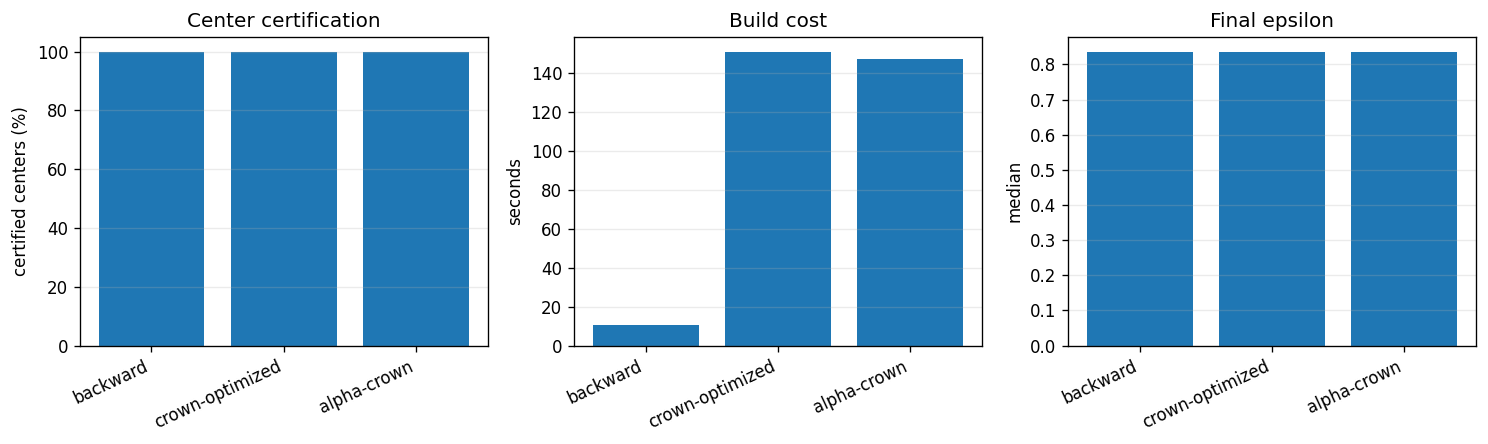

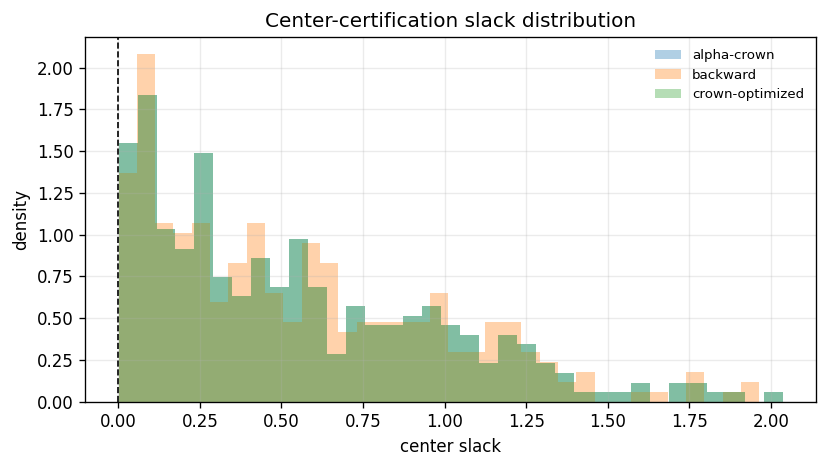

In [4]:
if LIRPA_SUMMARY_DF.empty:
    raise RuntimeError('No successful LiRPA runs to plot.')

plot_df = (
    LIRPA_SUMMARY_DF
    .set_index('lirpa_method')
    .reindex([m for m in LIRPA_METHODS if m in set(LIRPA_SUMMARY_DF['lirpa_method'])])
    .reset_index()
)
method_order = plot_df['lirpa_method'].tolist()
x = np.arange(len(method_order))

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8))
axes[0].bar(x, plot_df['center_certified_pct'])
axes[1].bar(x, plot_df['build_time_s'])
axes[2].bar(x, plot_df['eps_final_median'])

axes[0].set_title('Center certification')
axes[0].set_ylabel('certified centers (%)')
axes[1].set_title('Build cost')
axes[1].set_ylabel('seconds')
axes[2].set_title('Final epsilon')
axes[2].set_ylabel('median')

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(method_order, rotation=25, ha='right')
    ax.grid(True, axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7.0, 4.0))
for lirpa_method, sub in LIRPA_POLYTOPE_DF.groupby('lirpa_method', observed=True):
    ax.hist(
        sub['center_slack'].replace([np.inf, -np.inf], np.nan).dropna(),
        bins=35,
        alpha=0.35,
        density=True,
        label=lirpa_method,
    )
ax.axvline(0.0, color='black', linewidth=1.0, linestyle='--')
ax.set_xlabel('center slack')
ax.set_ylabel('density')
ax.set_title('Center-certification slack distribution')
ax.grid(True, alpha=0.25)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()


## Estimate Certified Volume By LiRPA Backend


In [11]:
import math
N_VOLUME_SAMPLES = 1024
VOLUME_TOL = 1.0e-8
volume_rng = np.random.default_rng(SEED + 911)


def sample_uniform_l1_ball(center: np.ndarray, eps: float, n_samples: int, rng: np.random.Generator) -> np.ndarray:
    center = np.asarray(center, dtype=np.float64)
    d = center.size
    expo = rng.exponential(scale=1.0, size=(n_samples, d + 1))
    magnitudes = expo[:, :d] / expo.sum(axis=1, keepdims=True)
    signs = rng.choice(np.array([-1.0, 1.0]), size=(n_samples, d))
    return center[None, :] + float(eps) * signs * magnitudes


def log_l1_ball_volume(eps: float, dim: int) -> float:
    if eps <= 0:
        return -np.inf
    return dim * np.log(2.0) + dim * np.log(float(eps)) - float(math.lgamma(dim + 1))


def mean_exp_log(values: pd.Series) -> float:
    arr = np.asarray(values, dtype=np.float64)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return np.nan
    m = float(arr.max())
    return float(np.exp(m) * np.mean(np.exp(arr - m)))


def estimate_volume_diagnostics(method: CertCF, lirpa_method: str, variant: str, n_samples: int = N_VOLUME_SAMPLES) -> pd.DataFrame:
    rows = []
    atlas = method.atlas
    for label in atlas.class_labels:
        bd = atlas.bounds[int(label)]
        centers = np.asarray(bd['X'], dtype=np.float64)
        eps_final = np.asarray(bd['eps'], dtype=np.float64)
        eps_initial = np.asarray(bd.get('eps_initial', eps_final), dtype=np.float64)
        certified = np.asarray(bd.get('adaptive_eps_center_certified', np.ones(len(centers), dtype=bool)), dtype=bool)
        lA = np.asarray(bd['lA'], dtype=np.float64)
        lbias = np.asarray(bd['lbias'], dtype=np.float64)
        dim = centers.shape[1]
        for idx, center in enumerate(centers):
            eps = float(eps_final[idx])
            samples = sample_uniform_l1_ball(center, eps, n_samples, volume_rng)
            A = lA[idx].reshape(-1, dim)
            b = lbias[idx].reshape(-1)
            if len(b):
                slack = samples @ A.T + b[None, :] - CLASSIFICATION_MARGIN
                inside = np.all(slack >= -VOLUME_TOL, axis=1)
            else:
                inside = np.ones(n_samples, dtype=bool)
            retained = float(inside.mean())
            retained_for_log = max(retained, 0.5 / n_samples)
            log_ball = log_l1_ball_volume(eps, dim)
            rows.append({
                'lirpa_method': lirpa_method,
                'variant': variant,
                'class_label': int(label),
                'polytope_idx': int(idx),
                'dim': int(dim),
                'eps_initial': float(eps_initial[idx]),
                'eps_final': eps,
                'eps_ratio': float(eps / eps_initial[idx]) if eps_initial[idx] > 0 else np.nan,
                'center_certified': bool(certified[idx]),
                'retained_fraction': retained,
                'zero_hit': bool(retained == 0.0),
                'log_l1_ball_volume': log_ball,
                'log_estimated_polytope_volume': log_ball + np.log(retained_for_log),
            })
    return pd.DataFrame(rows)


volume_frames = []
for (lirpa_method, variant), method in FITTED_METHODS.items():
    print(f'estimating volume: {lirpa_method} | {variant}')
    volume_frames.append(estimate_volume_diagnostics(method, lirpa_method, variant))

LIRPA_VOLUME_DF = pd.concat(volume_frames, ignore_index=True) if volume_frames else pd.DataFrame()
if not LIRPA_VOLUME_DF.empty:
    assert LIRPA_VOLUME_DF['retained_fraction'].between(0.0, 1.0).all()

LIRPA_VOLUME_SUMMARY_DF = (
    LIRPA_VOLUME_DF
    .groupby(['lirpa_method', 'variant'], observed=True)
    .agg(
        n_polytopes=('retained_fraction', 'size'),
        retained_mean=('retained_fraction', 'mean'),
        retained_std=('retained_fraction', 'std'),
        retained_min=('retained_fraction', 'min'),
        retained_q05=('retained_fraction', lambda s: float(np.quantile(s, 0.05))),
        retained_q25=('retained_fraction', lambda s: float(np.quantile(s, 0.25))),
        retained_median=('retained_fraction', 'median'),
        retained_q75=('retained_fraction', lambda s: float(np.quantile(s, 0.75))),
        retained_q95=('retained_fraction', lambda s: float(np.quantile(s, 0.95))),
        retained_max=('retained_fraction', 'max'),
        retained_iqr=('retained_fraction', lambda s: float(np.quantile(s, 0.75) - np.quantile(s, 0.25))),
        zero_hit_pct=('zero_hit', lambda s: 100.0 * float(np.mean(s))),
        log_l1_ball_volume_median=('log_l1_ball_volume', 'median'),
        log_estimated_polytope_volume_mean=('log_estimated_polytope_volume', lambda s: float(np.log(mean_exp_log(s)))),
        log_estimated_polytope_volume_median=('log_estimated_polytope_volume', 'median'),
        estimated_polytope_volume_mean=('log_estimated_polytope_volume', mean_exp_log),
        eps_final_median=('eps_final', 'median'),
        eps_ratio_median=('eps_ratio', 'median'),
    )
    .reset_index()
)

display(LIRPA_VOLUME_SUMMARY_DF.round(4))


estimating volume: backward | adaptive shrink
estimating volume: crown-optimized | adaptive shrink
estimating volume: alpha-crown | adaptive shrink


,lirpa_method,variant,n_polytopes,retained_mean,retained_std,retained_min,retained_q05,retained_q25,retained_median,retained_q75,retained_q95,retained_max,retained_iqr,zero_hit_pct,log_l1_ball_volume_median,log_estimated_polytope_volume_mean,log_estimated_polytope_volume_median,estimated_polytope_volume_mean,eps_final_median,eps_ratio_median
0,alpha-crown,adaptive shrink,300,0.9849,0.0679,0.5342,0.9234,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,-39.7772,14.6039,-39.7772,2199796.1438,0.8363,0.5000
1,backward,adaptive shrink,300,0.9706,0.0889,0.5107,0.7449,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,-39.8133,-1.3385,-39.8133,0.2622,0.8349,0.5000
2,crown-optimized,adaptive shrink,300,0.9847,0.0678,0.5156,0.9319,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,-39.7772,14.6039,-39.7772,2199796.1438,0.8363,0.5000


## Visualize Volume Differences


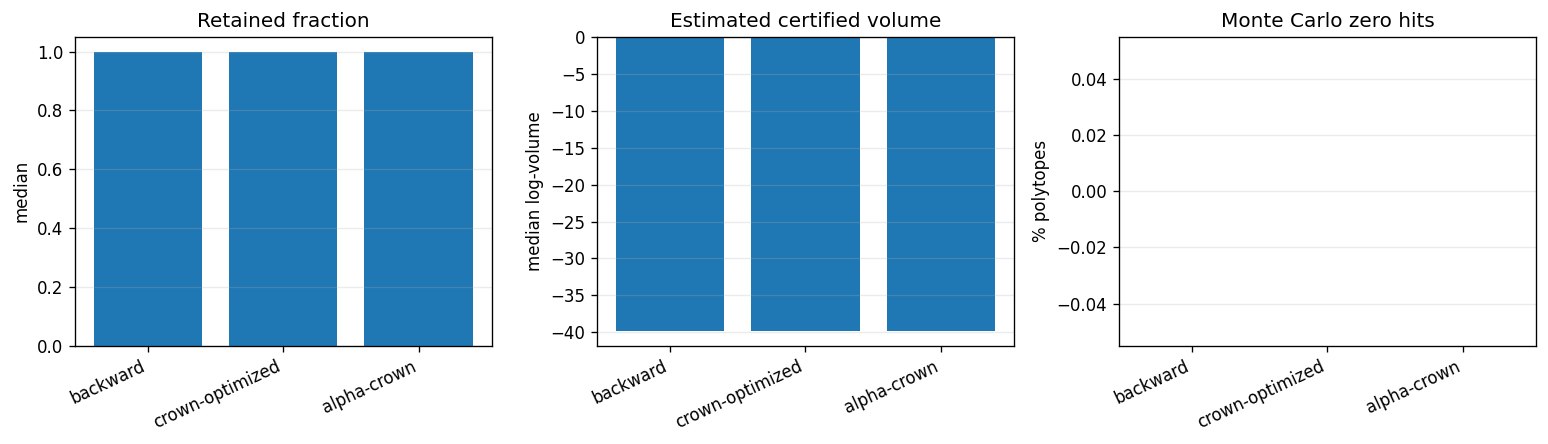

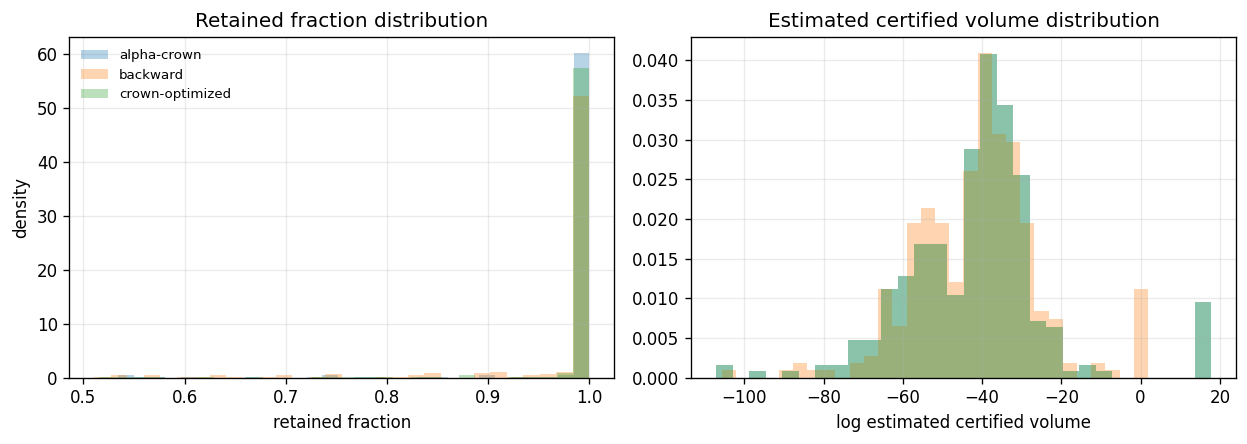

In [12]:
if LIRPA_VOLUME_DF.empty:
    raise RuntimeError('No volume diagnostics to plot.')

plot_df = (
    LIRPA_VOLUME_SUMMARY_DF
    .set_index('lirpa_method')
    .reindex([m for m in LIRPA_METHODS if m in set(LIRPA_VOLUME_SUMMARY_DF['lirpa_method'])])
    .reset_index()
)
method_order = plot_df['lirpa_method'].tolist()
x = np.arange(len(method_order))

fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.8), sharex=True)
axes[0].bar(x, plot_df['retained_median'])
axes[1].bar(x, plot_df['log_estimated_polytope_volume_median'])
axes[2].bar(x, plot_df['zero_hit_pct'])

axes[0].set_title('Retained fraction')
axes[0].set_ylabel('median')
axes[1].set_title('Estimated certified volume')
axes[1].set_ylabel('median log-volume')
axes[2].set_title('Monte Carlo zero hits')
axes[2].set_ylabel('% polytopes')

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(method_order, rotation=25, ha='right')
    ax.grid(True, axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
for lirpa_method, sub in LIRPA_VOLUME_DF.groupby('lirpa_method', observed=True):
    axes[0].hist(sub['retained_fraction'], bins=30, alpha=0.32, density=True, label=lirpa_method)
    axes[1].hist(sub['log_estimated_polytope_volume'], bins=30, alpha=0.32, density=True, label=lirpa_method)
axes[0].set_xlabel('retained fraction')
axes[0].set_ylabel('density')
axes[0].set_title('Retained fraction distribution')
axes[1].set_xlabel('log estimated certified volume')
axes[1].set_title('Estimated certified volume distribution')
for ax in axes:
    ax.grid(True, alpha=0.25)
axes[0].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()


## Basic Counterfactual Metrics

Run a small shared query set through each fitted LiRPA backend and summarize validity, $L_1$ proximity, and $L_0$ sparsity.


In [13]:
N_QUERIES = 200
L0_TOL = 1.0e-6

x_test, y_test = dataset.get_test()
y_test_pred = model.predict(x_test).astype(np.int64)
query_idx = stratified_indices(y_test_pred, N_QUERIES, np.random.default_rng(SEED + 1234))
x_query = x_test[query_idx]
y_query_pred = y_test_pred[query_idx]
target_classes = 1 - y_query_pred

cf_rows = []
for (lirpa_method, variant), method in FITTED_METHODS.items():
    print(f'querying: {lirpa_method} | {variant}')
    t0 = time.perf_counter()
    results = method.generate_batch(x_query, target_class=target_classes)
    total_s = time.perf_counter() - t0
    for query_pos, (x0, target, result) in enumerate(zip(x_query, target_classes, results)):
        success = bool(result.success and result.x_cf is not None)
        if success:
            x_cf = np.asarray(result.x_cf, dtype=np.float64)
            diff = np.abs(x_cf - np.asarray(x0, dtype=np.float64))
            y_cf = int(model.predict(x_cf.reshape(1, -1))[0])
            l1 = float(diff.sum())
            l2 = float(np.linalg.norm(diff, ord=2))
            l0 = int(np.sum(diff > L0_TOL))
            valid = bool(y_cf == int(target))
        else:
            y_cf = None
            l1 = np.nan
            l2 = np.nan
            l0 = np.nan
            valid = False
        cf_rows.append({
            'lirpa_method': lirpa_method,
            'variant': variant,
            'query_idx': int(query_idx[query_pos]),
            'target_class': int(target),
            'success': success,
            'valid': valid,
            'l1': l1,
            'l2': l2,
            'l0': l0,
            'l0_fraction': float(l0 / x_query.shape[1]) if success else np.nan,
            'query_time_s': float(total_s / max(len(results), 1)),
            'n_qp_solved': result.metadata.get('n_qp_solved', np.nan),
            'anchor_idx': result.metadata.get('anchor_idx', np.nan),
        })

LIRPA_CF_RESULTS_DF = pd.DataFrame(cf_rows)
LIRPA_CF_SUMMARY_DF = (
    LIRPA_CF_RESULTS_DF
    .groupby(['lirpa_method', 'variant'], observed=True)
    .agg(
        n_queries=('success', 'size'),
        validity_pct=('valid', lambda s: 100.0 * float(np.mean(s))),
        success_pct=('success', lambda s: 100.0 * float(np.mean(s))),
        l1_mean=('l1', 'mean'),
        l1_median=('l1', 'median'),
        l2_mean=('l2', 'mean'),
        l0_mean=('l0', 'mean'),
        l0_median=('l0', 'median'),
        l0_fraction_mean=('l0_fraction', 'mean'),
        query_time_s_mean=('query_time_s', 'mean'),
        n_qp_solved_mean=('n_qp_solved', 'mean'),
    )
    .reset_index()
    .sort_values('lirpa_method', ignore_index=True)
)

display(LIRPA_CF_SUMMARY_DF.round(4))


querying: backward | adaptive shrink
querying: crown-optimized | adaptive shrink
querying: alpha-crown | adaptive shrink


,lirpa_method,variant,n_queries,validity_pct,success_pct,l1_mean,l1_median,l2_mean,l0_mean,l0_median,l0_fraction_mean,query_time_s_mean,n_qp_solved_mean
0,alpha-crown,adaptive shrink,200,100.0000,100.0000,11.6810,9.2648,3.6564,16.3750,17.0000,0.7120,0.0137,4.8500
1,backward,adaptive shrink,200,100.0000,100.0000,11.6398,9.2010,3.6512,16.3150,16.5000,0.7093,0.0134,4.8500
2,crown-optimized,adaptive shrink,200,100.0000,100.0000,11.6810,9.2648,3.6564,16.3750,17.0000,0.7120,0.0132,4.8500
